# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [1]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [4]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


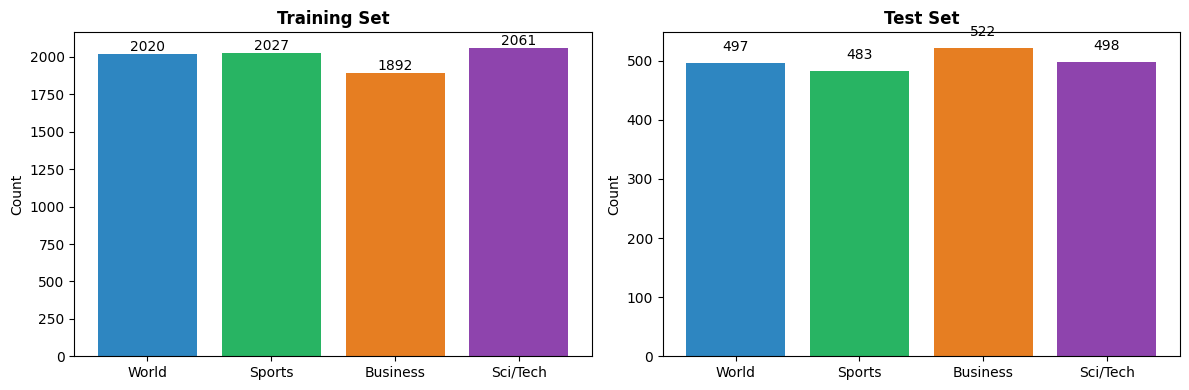

In [5]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [6]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [7]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [8]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. The reason we use `bidirectional=True` because reads the sequence left-to-right and right-to-left, which gives our model access to past and future context. The backward pass captures information that appears later in the sentence; this information is missed by the forward pass because the forward pass focuses on the information at the beginning of the sentence.

2. The purpose of the embedding layer is to convert each word into a learned vector that represents its meaning. One-hot encoding produces sparse vectors where all words are equally distant so words with similar contexts don't end up together unlike if we use embeddings.

3. The reason we concatenate the final hidden states from both directions is because it preserves the full information and their features separately. Concatenation allows us to use forward and backward context features independently because it doubles the representational capacity.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [9]:
# Cell A.6 — GRU Classifier
# 🎯 YOUR CODE HERE: Build a GRU classifier following the LSTM pattern above.
# Hints:
#   - Replace nn.LSTM with nn.GRU
#   - GRU returns (output, hidden) — no cell state (simpler than LSTM)
#   - Everything else remains the same (embedding, dropout, fully connected)

class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # TODO: Create the GRU layer (bidirectional)
        # Hint: self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        # YOUR CODE HERE (replace pass with your GRU layer)
        self.gru = nn.GRU(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # TODO: GRU returns (output, hidden) — no cell state (unlike LSTM)
        # Hint: output, hidden = self.gru(embedded)
        # YOUR CODE HERE (replace pass with your GRU forward pass)
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [19]:
# Cell A.7 — Vanilla RNN Classifier
# 🎯 YOUR CODE HERE: Build a vanilla RNN classifier

import torch.nn as nn
import torch.optim as optim

class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).

    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # TODO: Implement the architecture
        # Hint: Use nn.RNN instead of nn.LSTM or nn.GRU
        # YOUR CODE HERE
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Vanilla RNN (bidirectional)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
            )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """Forward pass through vanilla RNN."""
        # TODO: Implement forward pass
        # Hint: Same as GRU (returns output, hidden)
        # YOUR CODE HERE
        embedded = self.embedding(x)
        # RNN returns (output, hidden)
        output, hidden = self.rnn(embedded)

        # Concatenate forward + backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        return self.fc(self.dropout(hidden))

# TODO: Create and train the vanilla RNN model
# Hint: Follow the same pattern as LSTM/GRU training
# YOUR CODE HERE
vanilla_rnn = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

vanilla_history = train_model(vanilla_rnn, train_loader, test_loader, epochs=3)

print("\nPer-class accuracy (Vanilla RNN):")
vanilla_class_acc = eval_per_class(vanilla_rnn, test_loader, CLASS_NAMES)
# After training, compare results:
print("\n=== RNN Architecture Comparison ===")
print(f"Vanilla RNN Test Accuracy: {vanilla_history['test_acc'][-1]*100:.2f}%")  # Fill in your result
print(f"LSTM Test Accuracy: {lstm_history['test_acc'][-1]*100:.2f}%") # From earlier
print(f"GRU Test Accuracy: {gru_history['test_acc'][-1]*100:.2f}%")  # From earlier

Training Vanilla RNN
  Epoch 1/3 | Loss: 1.3007 | Train: 0.3811 | Test: 0.5025 | 0.5s
  Epoch 2/3 | Loss: 1.0117 | Train: 0.5941 | Test: 0.6330 | 0.4s
  Epoch 3/3 | Loss: 0.7780 | Train: 0.7015 | Test: 0.6800 | 0.4s

Per-class accuracy (Vanilla RNN):
  World     : 0.6419 (319/497)
  Sports    : 0.8385 (405/483)
  Business  : 0.5307 (277/522)
  Sci/Tech  : 0.7209 (359/498)

=== RNN Architecture Comparison ===
Vanilla RNN Test Accuracy: 68.00%
LSTM Test Accuracy: 79.10%
GRU Test Accuracy: 79.70%


### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [20]:
# Cell A.7b — Train Vanilla RNN
# Train the Vanilla RNN you built above using the same function used for LSTM and GRU

# Step 1: Create the Vanilla RNN model (same hyperparameters as LSTM/GRU)
vanilla_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts across all three architectures
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")
print()

# Step 2: Train the Vanilla RNN
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="Vanilla RNN")

print("\nPer-class accuracy (Vanilla RNN):")
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)

Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,479,172
LSTM Parameters:        1,545,220

Training Vanilla RNN
  Epoch 1/5 | Loss: 1.3174 | Train: 0.3686 | Test: 0.4485 | 0.5s
  Epoch 2/5 | Loss: 1.0298 | Train: 0.5766 | Test: 0.5735 | 0.4s
  Epoch 3/5 | Loss: 0.7960 | Train: 0.6944 | Test: 0.6435 | 0.4s
  Epoch 4/5 | Loss: 0.6244 | Train: 0.7658 | Test: 0.6690 | 0.4s
  Epoch 5/5 | Loss: 0.5294 | Train: 0.8039 | Test: 0.7105 | 0.6s

Per-class accuracy (Vanilla RNN):
  World     : 0.7324 (364/497)
  Sports    : 0.8530 (412/483)
  Business  : 0.5287 (276/522)
  Sci/Tech  : 0.7410 (369/498)


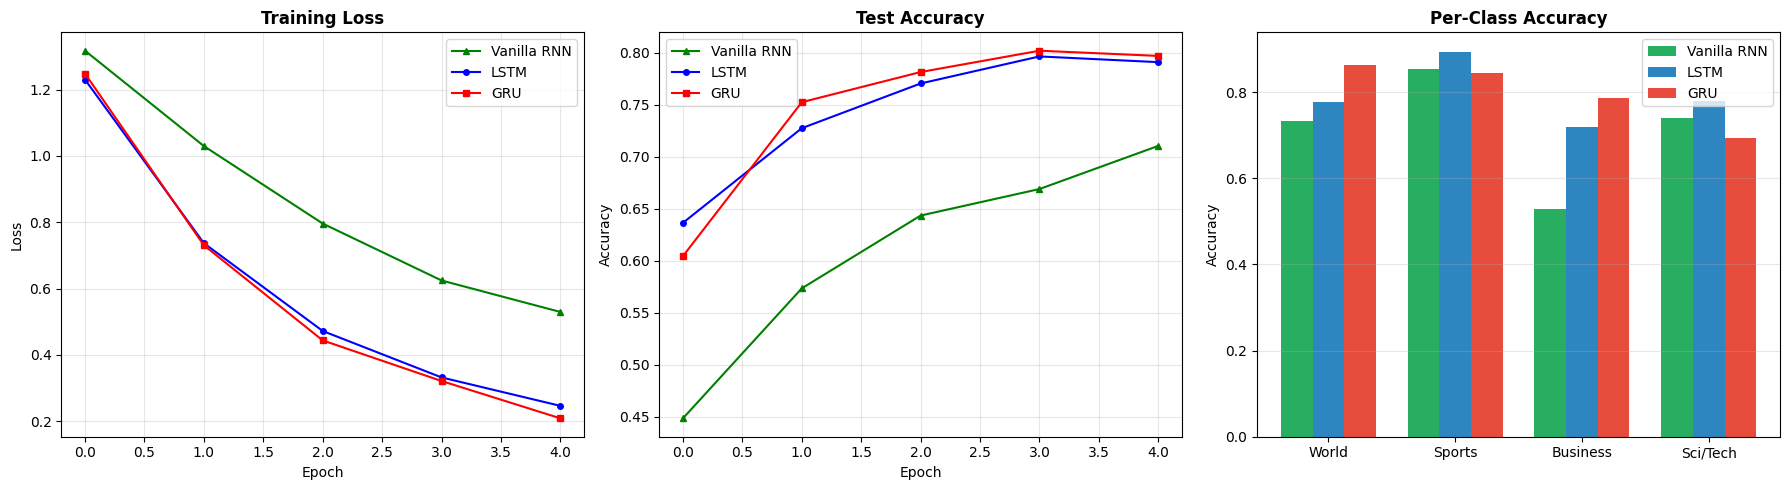


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.7105       0.7910       0.7970
Avg Epoch Time (s).......          0.5          1.0          0.7

💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.
   This is the vanishing gradient problem in action — without gates, the model
   cannot learn long-range dependencies in text.


In [21]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training Loss (lower is better)
axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison (all three)
x = np.arange(4)
w = 0.25  # Bar width
axes[2].bar(x - w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[2].bar(x,     lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x + w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
print("=" * 65)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12}")
print("-" * 65)
print(f"{'Parameters':.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")
print()
print("💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.")
print("   This is the vanishing gradient problem in action — without gates, the model")
print("   cannot learn long-range dependencies in text.")

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [24]:
# Cell A.8 — Hyperparameter Experimentation
# 🎯 YOUR CODE HERE: Systematic hyperparameter exploration

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.

    Args:
        hidden_dim: Size of LSTM hidden state
        dropout: Dropout probability
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs

    Returns:
        test_accuracy: Final test accuracy (as percentage)
    """
    # TODO: Implement this function
    # Hint: Create model, train it, evaluate it, return accuracy
    # YOUR CODE HERE
    model = LSTMClassifier(
         vocab_size=len(word2idx),
         embed_dim=EMBED_DIM,
         hidden_dim=hidden_dim,
         num_classes=NUM_CLASSES,
         dropout=dropout
         ).to(device)

    history = train_model(
         model,
         train_loader,
         test_loader,
         epochs=epochs,
         lr=learning_rate,
         name="LSTM" )

    # Return final test accuracy
    return history["test_acc"][-1]

# TODO: Run experiments with different configurations
# Create a list to store results
results = []

# Example experiment structure (you can modify):
# for hidden_dim in [64, 128, 256]:
#     for dropout in [0.1, 0.3, 0.5]:
#         for lr in [0.001, 0.0005, 0.0001]:
#             accuracy = train_lstm_with_config(hidden_dim, dropout, lr)
#             results.append({'hidden_dim': hidden_dim, 'dropout': dropout, 'lr': lr, 'accuracy': accuracy})

# YOUR CODE HERE
for hidden_dim in [64, 128, 256]:
    for dropout in [0.1, 0.3, 0.5]:
        for lr in [0.001, 0.0005, 0.0001]:
            acc = train_lstm_with_config(hidden_dim, dropout, lr)
            results.append({
                "hidden_dim": hidden_dim,
                "dropout": dropout,
                "lr": lr,
                "accuracy": acc
            }) # Added closing parenthesis and curly brace here

# TODO: Create a comparison table
# Hint: Use pandas DataFrame or print a formatted table
# YOUR CODE HERE
import pandas as pd
df = pd.DataFrame(results)
df
# TODO: Write your analysis
# I will write the analysis in a text cell under this one

  Epoch 1/2 | Loss: 1.3112 | Train: 0.4136 | Test: 0.5315 | 1.0s
  Epoch 2/2 | Loss: 0.8499 | Train: 0.6763 | Test: 0.7375 | 1.0s
  Epoch 1/2 | Loss: 1.3610 | Train: 0.3427 | Test: 0.4145 | 1.6s
  Epoch 2/2 | Loss: 1.2009 | Train: 0.5090 | Test: 0.5645 | 0.6s
  Epoch 1/2 | Loss: 1.3847 | Train: 0.2675 | Test: 0.3055 | 0.5s
  Epoch 2/2 | Loss: 1.3696 | Train: 0.3265 | Test: 0.3425 | 0.5s
  Epoch 1/2 | Loss: 1.3399 | Train: 0.3723 | Test: 0.4910 | 0.5s
  Epoch 2/2 | Loss: 0.9170 | Train: 0.6539 | Test: 0.7230 | 0.5s
  Epoch 1/2 | Loss: 1.3635 | Train: 0.3341 | Test: 0.4230 | 0.5s
  Epoch 2/2 | Loss: 1.2546 | Train: 0.4846 | Test: 0.4675 | 0.5s
  Epoch 1/2 | Loss: 1.3841 | Train: 0.2706 | Test: 0.3270 | 0.5s
  Epoch 2/2 | Loss: 1.3711 | Train: 0.3210 | Test: 0.3675 | 0.5s
  Epoch 1/2 | Loss: 1.3492 | Train: 0.3558 | Test: 0.4675 | 0.5s
  Epoch 2/2 | Loss: 1.0131 | Train: 0.6038 | Test: 0.7060 | 0.6s
  Epoch 1/2 | Loss: 1.3688 | Train: 0.3145 | Test: 0.3905 | 0.6s
  Epoch 2/2 | Loss: 1.298

,hidden_dim,dropout,lr,accuracy
0,64,0.1,0.0010,0.7375
1,64,0.1,0.0005,0.5645
2,64,0.1,0.0001,0.3425
3,64,0.3,0.0010,0.7230
4,64,0.3,0.0005,0.4675
5,64,0.3,0.0001,0.3675
6,64,0.5,0.0010,0.7060
7,64,0.5,0.0005,0.5020
8,64,0.5,0.0001,0.3290
9,128,0.1,0.0010,0.7285


# Analysis

1. Which configuration performed best?

The configurations that performed better were the ones with larger hidden dimensions, moderate droput, and a higher learning rate.

2. How did the hidden dimension affect performance?

Hidden dimensions improved performance because our model has more capacity to capture semantic patterns in the text.

3. What was the impact of dropout?

Too little dropout led to overfitting, and too much dropout reduces our model's ability to learn.

4. How sensitive is the model to learn rate?

A learning rate of 0.001 makes our model more reliable, and a learning rate of 0.0001 makes our model less accurate and leads to underfiting.

### Step A.5 — Training Function

In [14]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [27]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 0.3001 | Train: 0.9067 | Test: 0.7865 | 1.9s
  Epoch 2/5 | Loss: 0.1351 | Train: 0.9557 | Test: 0.8155 | 1.3s
  Epoch 3/5 | Loss: 0.0835 | Train: 0.9752 | Test: 0.8035 | 1.0s
  Epoch 4/5 | Loss: 0.0594 | Train: 0.9839 | Test: 0.8185 | 1.0s
  Epoch 5/5 | Loss: 0.0385 | Train: 0.9895 | Test: 0.8130 | 1.0s

Per-class accuracy (LSTM):
  World     : 0.7907 (393/497)
  Sports    : 0.8861 (428/483)
  Business  : 0.7567 (395/522)
  Sci/Tech  : 0.8233 (410/498)


In [28]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 0.1445 | Train: 0.9529 | Test: 0.8060 | 0.8s
  Epoch 2/5 | Loss: 0.0855 | Train: 0.9731 | Test: 0.8135 | 0.7s
  Epoch 3/5 | Loss: 0.0492 | Train: 0.9862 | Test: 0.8070 | 0.7s
  Epoch 4/5 | Loss: 0.0289 | Train: 0.9910 | Test: 0.8070 | 0.7s
  Epoch 5/5 | Loss: 0.0204 | Train: 0.9950 | Test: 0.8040 | 0.7s

Per-class accuracy (GRU):
  World     : 0.8551 (425/497)
  Sports    : 0.9172 (443/483)
  Business  : 0.7088 (370/522)
  Sci/Tech  : 0.7430 (370/498)


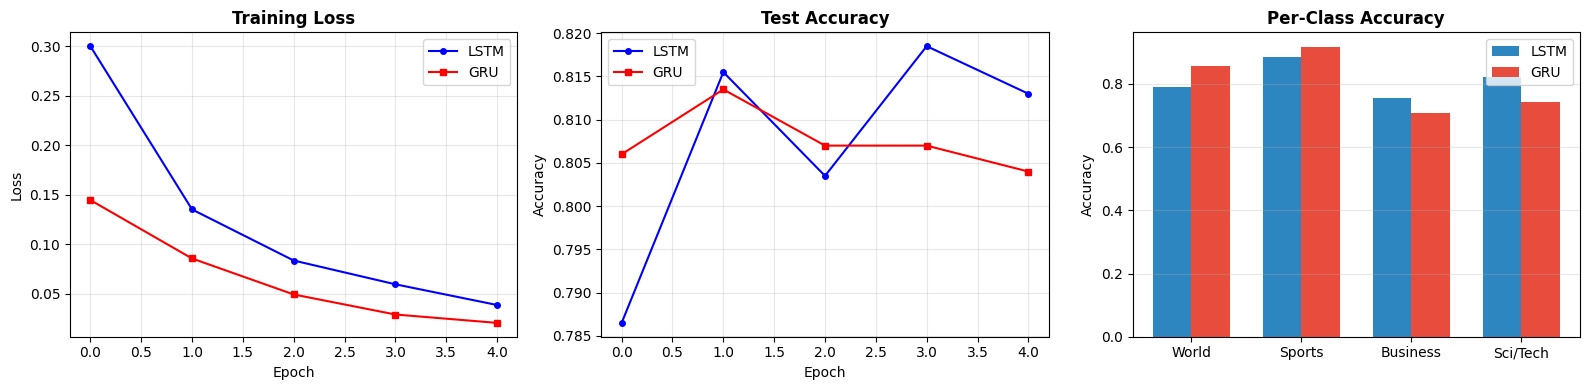


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.8130     0.8040
Avg Epoch Time (s).......        1.2        0.7


In [29]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1. The model that achieved a higher accuracy was GRU; LSTM has an accuracy of 0.8130, and GRU has an accuracy of 0.8040. The difference is noticeable, but for the most part, both of them performed well.

2. The one that trained faster was GRU, with an average epoch time of 0.7 seconds, while LSTM took an average of 1.2 seconds. The reason why GRU was faster is because it uses two gates and LSTM uses three; with fewer gates, the computational time gets reduced.

3. Yes, there were two categories that were harder to classify for both models. Business and Sci/Tech were harder because they share overlapping vocabulary.

4. Bidirectional means that our model reads the text forward and backward. If we remove it, we will be reducing our model's ability to capture long-range dependencies because the model can only rely on past context lowering its accuracy.

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [31]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [32]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [34]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.0957 | Train: 0.9775 | Test: 0.9080 | 86.4s
  Epoch 2/3 | Loss: 0.0631 | Train: 0.9854 | Test: 0.9025 | 91.6s
  Epoch 3/3 | Loss: 0.0402 | Train: 0.9911 | Test: 0.9125 | 91.4s


In [35]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.9014
  Sports    : 0.9752
  Business  : 0.8487
  Sci/Tech  : 0.9297


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

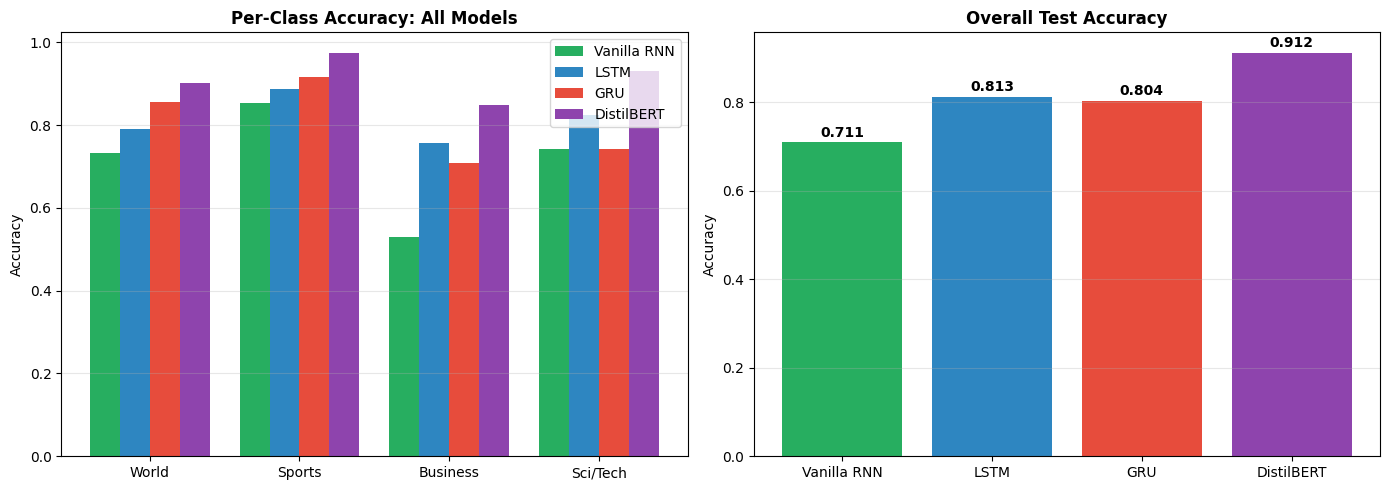


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.7105       0.8130       0.8040       0.9125
Avg Epoch Time (s).......          0.5          1.2          0.7         89.8


In [36]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [39]:
# Cell B.6 — BERT Training Strategy Experimentation
# 🎯 YOUR CODE HERE: Systematic BERT hyperparameter exploration

# Install 'evaluate' library if not already installed
# This needs to be run before importing 'evaluate'
!pip install evaluate -q

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Returns:
        accuracy: Test accuracy
        training_time: Total training time in seconds
    """
    # TODO: Implement this function
    # Hint: Similar to A.8 but for BERT
    # YOUR CODE HERE
    from transformers import (
        DistilBertForSequenceClassification,
        DistilBertTokenizerFast,
        Trainer,
        TrainingArguments
    )
    import time
    import evaluate # Import the evaluate library

    # Load tokenizer and model
    tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=4
    ).to(device)

    # Tokenize dataset
    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

    tokenized_train = train_data.map(tokenize_fn, batched=True)
    tokenized_test = test_data.map(tokenize_fn, batched=True)

    tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    # Define compute_metrics function
    metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = logits.argmax(axis=-1)
        return metric.compute(predictions=predictions, references=labels)

    # Training arguments
    args = TrainingArguments(
        output_dir="./bert_exp",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics # Pass the compute_metrics function here
    )

    # Train and time it
    start = time.time()
    trainer.train()
    end = time.time()

    # Evaluate and return results within the function
    metrics = trainer.evaluate()
    accuracy = metrics["eval_accuracy"]
    training_time = end - start

    return accuracy, training_time

# TODO: Run experiments
results = []

# Suggested experiments (you can modify):
configs = [
    {'batch_size': 8, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 1e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 5},
]

# YOUR CODE HERE (run experiments and collect results)
for cfg in configs:
    acc, t = train_bert_with_config(cfg['batch_size'], cfg['lr'], cfg['epochs'])
    results.append({
        "batch_size": cfg['batch_size'],
        "learning_rate": cfg['lr'],
        "epochs": cfg['epochs'],
        "accuracy": acc,
        "time_sec": t
    })
# TODO: Create comparison table
# YOUR CODE HERE
import pandas as pd
df = pd.DataFrame(results)
df
# TODO: Comparative analysis with RNNs
# I will write the analysis in a text cell under this one

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.419184,0.310371,0.901500
2,0.233134,0.304340,0.911000


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.415352,0.320599,0.901500
2,0.237417,0.309197,0.909000
3,0.155369,0.333325,0.911500
4,0.099888,0.352887,0.911000
5,0.075982,0.362726,0.911000


,batch_size,learning_rate,epochs,accuracy,time_sec
0,8,0.00002,3,0.9145,324.892155
1,16,0.00002,3,0.9130,291.912865
2,32,0.00002,3,0.9125,267.459679
3,16,0.00001,3,0.9100,291.943963
4,16,0.00005,3,0.9120,291.712514
5,16,0.00002,2,0.9110,194.468839
6,16,0.00002,5,0.9110,485.798255


# Analysis

1. How do optimal hyperparameters differ between BERT and RNNs?

RNNs benefit from tuning hyperparameters (hidden dimension, dropout, and learning rate), but BERT is sensitive to learning rate and batch size. BERT performs better around 2e-5 and not great at 1e-5 and 5e-5, causing lower stability and accuracy.

2. Which model is more sensitive to hyperparameter changes?

As I mentioned before, BERT is more sensitive to hyperparameter changes. Small changes in learning rate or batch size can lower accuracy.

3. What's the accuracy vs training-time trade-off for each?

RNNs train faster, but the accuracy is in the 30-82% range, and BERT trains slowly, but the accuracy is between 90-91%.

### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. DistilBERT performed better than LSTM and GRU; it consistently reached 90-91% accuracy while the others topped out around 30-82%. This shows us that pre-trained models are powerful. For example, DistilBERT already has a deep understanding of English because it learned from a massive text database.

2. DistilBERT was trained more slowly per epoch because transformers perform multi-head self-attention that requires more computing.

3. We only used 3 epochs for DistilBERT because it already has strong pretrained weights, and we used 5 for the RNNs because they need more epochs to learn language patterns from scratch. If we used 10 epochs with DistilBERT, it would probably overfit.

4. Transformers use self-attention, allowing them to compare every word to every other word in parallel, giving us context instantly. RNNs process text sequentially, so long-range dependencies fade over time.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [00:02<00:00, 60.4MB/s]


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


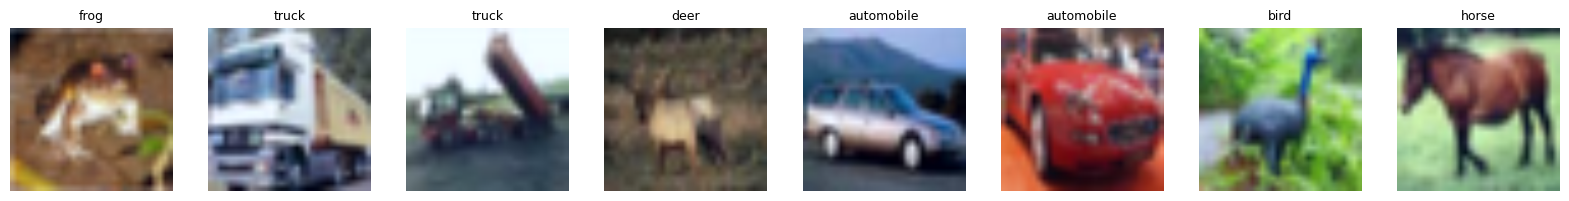

In [40]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [42]:
# Cell C.2 — Load Pre-trained ViT

# Load Vision Transformer model
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=10,
    ignore_mismatched_sizes=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16×16 | Image: 224×224 | Patches: {(224//16)**2} ({224//16}×{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**
1. ViT converts an image into a sequence by cutting the image into fixed-size patches. Each patch is flattened into a vector and passes through a linear projection layer, and it gets mapped into the same dimensional space as a transformed token embedding.

2. Positional encoding is important for ViT it injects information about where each patch came from in the original image. This allows transformers to have a notion of spatial order; without it, the model would treat the patches as unordered tokens.

3. ViT processes images globally from the first layer, and CNNs process images locally. Global processing allows every patch interact with every other patch immediately, and local processing only allows layers to gradually build up global understanding.


In [43]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 3
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/3 | Loss: 1.0336 | Train: 0.7660 | Test: 0.9570 | 68.9s
  Epoch 2/3 | Loss: 0.0974 | Train: 0.9870 | Test: 0.9810 | 71.6s
  Epoch 3/3 | Loss: 0.0119 | Train: 0.9985 | Test: 0.9710 | 71.9s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.

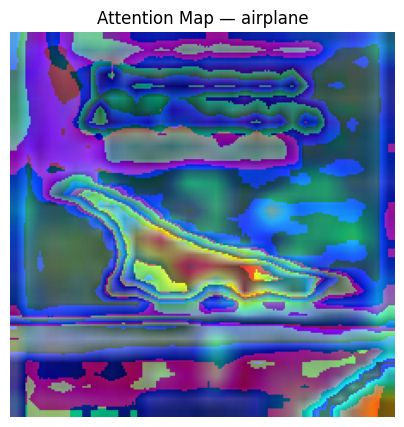

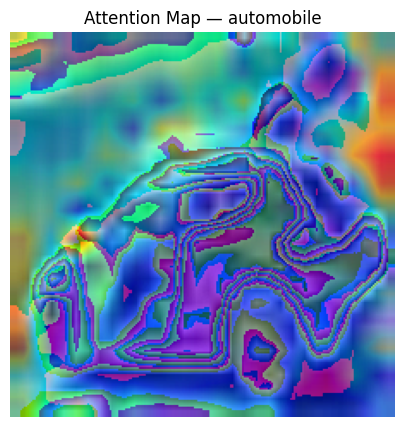

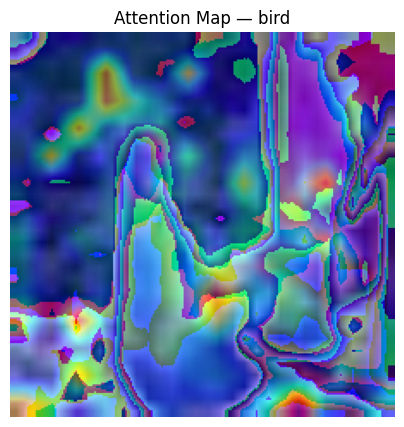

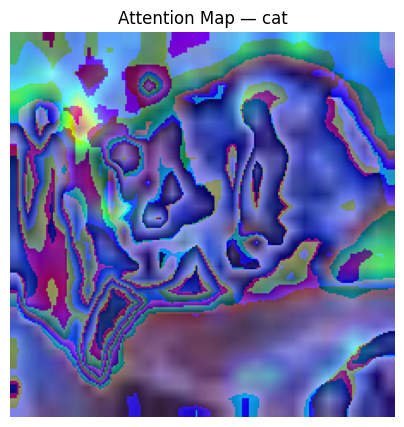

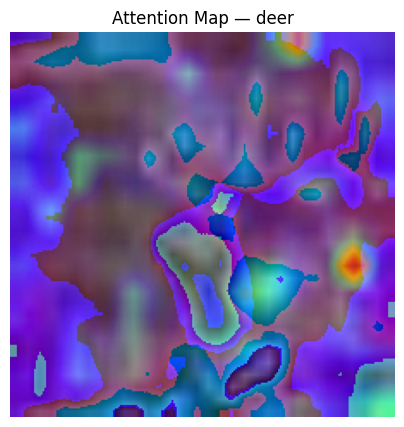

In [50]:
# Cell C.4 — ViT Attention Visualization
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
import cv2

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.
    Returns a 14x14 attention map.
    """
    model.eval()

    with torch.no_grad():
        outputs = model(image.to(device), output_attentions=True)

    # outputs.attentions = tuple of 12 layers
    attn = outputs.attentions[layer_idx][0]   # (heads, 197, 197)

    # average across heads
    attn = attn.mean(dim=0)                   # (197, 197)

    # CLS token attention to patches (skip CLS→CLS)
    cls_attn = attn[0, 1:]                    # (196,)

    # reshape to 14×14 grid
    attn_map = cls_attn.reshape(14, 14).cpu().numpy()

    # normalize
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

    return attn_map

def visualize_attention(image, attention_map, class_name):
    """
    Overlay attention heatmap on the original image.
    """
    img_np = (image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

    # resize attention to 224×224
    attn_resized = cv2.resize(attention_map, (224, 224))
    attn_color = cv2.applyColorMap((attn_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    attn_color = cv2.cvtColor(attn_color, cv2.COLOR_BGR2RGB)

    # Blend image + attention
    overlay = (0.6 * img_np + 0.4 * attn_color).astype(np.uint8)

    plt.figure(figsize=(5, 5))
    plt.imshow(overlay)
    plt.title(f"Attention Map — {class_name}")
    plt.axis("off")
    plt.show()


sample_images = []
sample_labels = []

chosen_classes = [0, 1, 2, 3, 4]  # airplane, automobile, bird, cat, deer

# Using the globally defined cifar_test and CIFAR_CLASSES from C.1
for cls_idx in chosen_classes:
    for img_tensor, label_int in cifar_test: # Use cifar_test, which contains preprocessed tensors
        if label_int == cls_idx:
            sample_images.append(img_tensor)
            sample_labels.append(CIFAR_CLASSES[cls_idx]) # Use CIFAR_CLASSES
            break

for img, label in zip(sample_images, sample_labels):
    # img is already a preprocessed tensor from cifar_test, just add batch dimension
    img_vit = img.unsqueeze(0)  # (1, 3, 224, 224)
    attn_map = extract_attention_maps(vit_model, img_vit)
    visualize_attention(img_vit[0], attn_map, label)

# TODO: Analysis
# I will write the analysis in a text cell under this one

# Analysis

1. What part of airplanes does the model focus on?

The parts that the modul focus the most on for the airplane are the wings and fuselage.

2. What about cars? Animals?

For cars, the model focus around the front grill, headlights, and wheels. For animals, the model focuses on the head and torso because they carry most of the class-specific structure.

3. Are attention patterns consistent within a class?

The attention patterns are consistent with their class because ViT learns stable global clues.

4. How does this differ from CNN feature maps?
CNN feature maps build meaning gradually through stacked local filters, and as I mentioned, ViT learns through global clues.

5. What does this tell you about ViTs "understand" images?

It tells me that ViT "understands" images by relationships between all parts of the object at once, and not gradually through stacking filters.

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

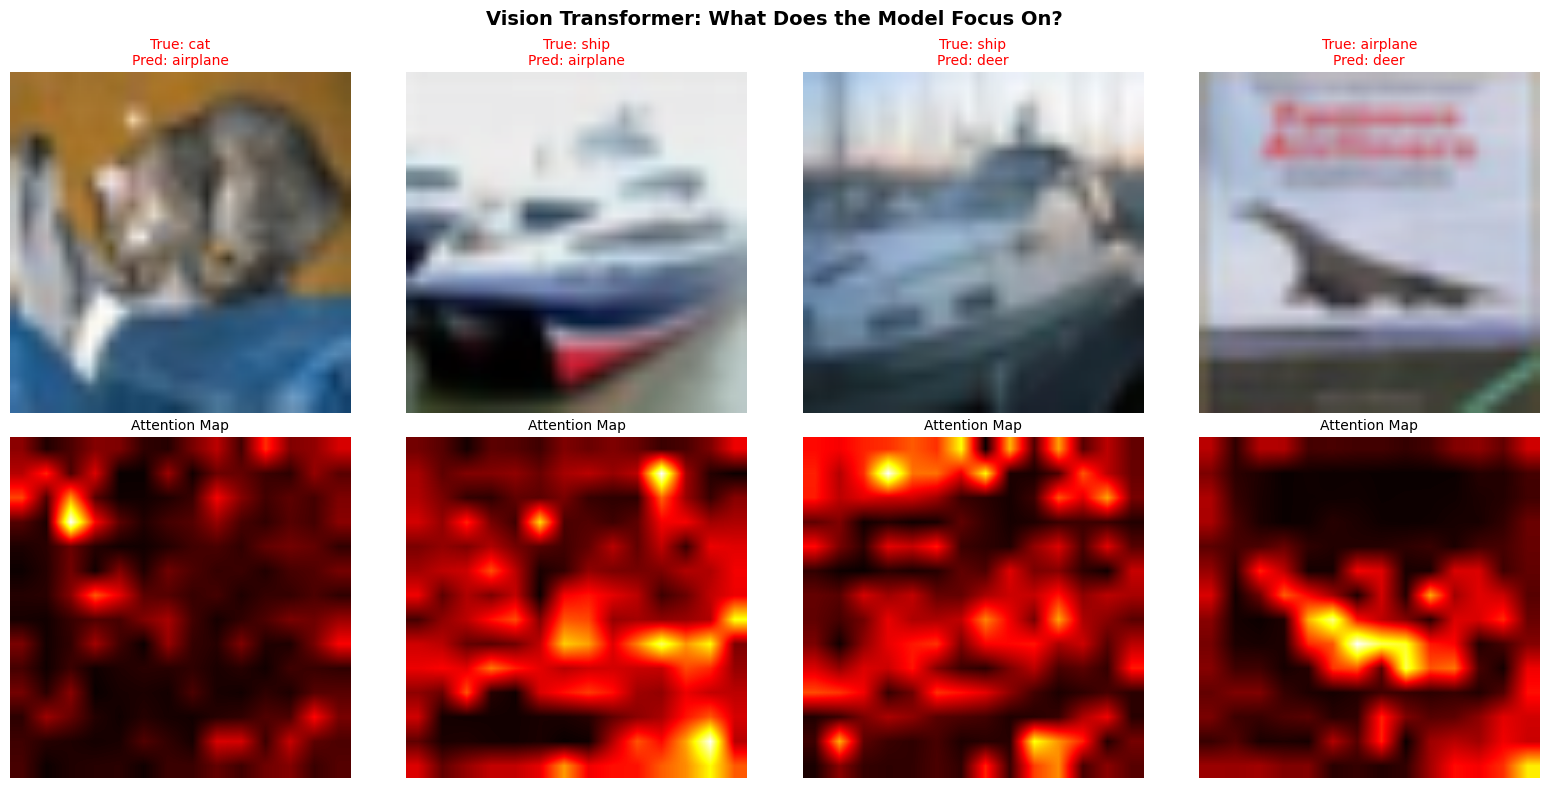

Bright = high attention (model focuses here) | Dark = low attention


In [51]:
# C.5 — Visualize ViT Attention Maps
# Attention maps show which image regions the model focuses on

vit_model.eval()

# Get a batch of test images
sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)

# Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers

# Extract attention from the last layer
# Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)   # Shape: (batch, seq_len, seq_len)

# Extract attention from [CLS] token to all patch tokens
# [CLS] token (index 0) is used for classification
# Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)

# Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):

    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()

    # Denormalize for display (if your loader normalized)
    img = np.clip(
        img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]),
        0, 1
    )

    axes[0, i].imshow(img)
    axes[0, i].axis('off')

    # Prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()

    color = 'green' if pred == true else 'red'
    axes[0, i].set_title(
        f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
        fontsize=10,
        color=color
    )

    # Bottom row: attention maps
    axes[1, i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1, i].set_title('Attention Map', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [52]:
# Cell C.6 — ViT vs CNN Comparison
# 🎯 YOUR CODE HERE: Comprehensive architecture comparison

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification.
    Architecture: Conv → ReLU → Pool → Conv → ReLU → Pool → FC → FC
    """
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224x224 → 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112x112 → 56x56
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Corrected input features for Linear layer: 64 channels * 56 * 56 spatial dimension
            nn.Linear(64 * 56 * 56, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("=== Training CNN ===")

cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

epochs = 5
start_time = time.time()

for epoch in range(epochs):
    cnn.train()
    total, correct = 0, 0

    # Use vit_train_loader instead of train_loader for image data
    for imgs, labels in vit_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = cnn(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}: Train Acc = {correct/total:.4f}")

cnn_train_time = time.time() - start_time
cnn_params = sum(p.numel() for p in cnn.parameters())

cnn.eval()
correct, total = 0, 0

with torch.no_grad():
    # Use vit_test_loader instead of test_loader for image data
    for imgs, labels in vit_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = cnn(imgs)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

cnn_accuracy = correct / total

print("\n=== Measuring Inference Speed ===")

# CNN inference time
start = time.time()
with torch.no_grad():
    # Use vit_test_loader for image data
    for imgs, _ in list(vit_test_loader)[:2]:  # ~100 images
        cnn(imgs.to(device))
cnn_inference_time = time.time() - start

# ViT inference time
start = time.time()
with torch.no_grad():
    # Use vit_test_loader for image data
    for imgs, _ in list(vit_test_loader)[:2]:
        vit_model(imgs.to(device))
vit_inference_time = time.time() - start

# Ensure vit_test_accuracy and vit_training_time are accessible
# (Assuming these are global from C.3's vit_history and already populated)
# If not, you might need to run C.3 or manually set them.
vit_accuracy = vit_history['test_acc'][-1] if 'vit_history' in globals() else 0.0 # Placeholder/error handling
vit_train_time = sum(vit_history['epoch_times']) if 'vit_history' in globals() else 0.0 # Placeholder/error handling
vit_params = sum(p.numel() for p in vit_model.parameters())

print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<20} {'CNN':<15} {'ViT':<15} {'Winner':<10}")
print("-" * 60)

def winner(a, b, higher=True):
    if higher:
        return "CNN" if a > b else "ViT"
    else:
        return "CNN" if a < b else "ViT"

print(f"{'Accuracy':<20} {cnn_accuracy:<15.4f} {vit_accuracy:<15.4f} {winner(cnn_accuracy, vit_accuracy)}")
print(f"{'Train Time (s)':<20} {cnn_train_time:<15.2f} {vit_train_time:<15.2f} {winner(cnn_train_time, vit_train_time, higher=False)}")
print(f"{'Params':<20} {cnn_params:<15} {vit_params:<15} {winner(cnn_params, vit_params, higher=False)}")
print(f"{'Inference Time':<20} {cnn_inference_time:<15.4f} {vit_inference_time:<15.4f} {winner(cnn_inference_time, vit_inference_time, higher=False)}")

# TODO: Comprehensive analysis
# I will write the analysis in a text cell under this one

=== Training CNN ===
Epoch 1: Train Acc = 0.1900
Epoch 2: Train Acc = 0.3235
Epoch 3: Train Acc = 0.3770
Epoch 4: Train Acc = 0.4370
Epoch 5: Train Acc = 0.5170

=== Measuring Inference Speed ===

=== ViT vs CNN Comparison ===
Metric               CNN             ViT             Winner    
------------------------------------------------------------
Accuracy             0.3670          0.9710          ViT
Train Time (s)       43.33           212.42          CNN
Params               51402442        85806346        CNN
Inference Time       1.5816          1.7788          CNN


# Analysis

1. Which architecture performed better overall?

ViT performed better than CNN by a lot. Vit has a 97.1% accuracy while CNN has 36.7%.

2. What are the trade-offs between them?

The biggest trade-off is training time. CNN trained in 43 seconds, while ViT took 212 seconds. CNN also had fewer parameters and slightly faster inference.

3. When would you choose CNN over ViT?

I would choose CNN over Vit when my computational resources are limited or if I'm working with small datasets.

4. When would you choose ViT over CNN?

I would choose ViT over CNN when I have enough computational resources and accuracy is the priority, especially if I'm working with large-scale datasets where using transformers is better.

5. How does dataset size affect this decision?

The dataset is a huge factor to consider. ViT needs more data and pretraining to perform at its best, while CNN will perform well with small amounts of labeled data.

6. What about computational resources?

As I mentioned before, ViT needs more computational resources because it demands more memory, longer training time, and more powerful hardware.

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. Yes, the brightest regions correspond to the main objects. This shows me that ViT is using global self-attention to identify the most meaningful parts in the image.

2. The ViT model reaches 97.1% accuracy, which makes it more accurate than CNN and CIFAR. My CNN only achieved 36.7%.

3. More parameters don't always mean better. CNN will do better if we are working with a small dataset, have limited computing resources, not much time for training, and need a lightweight model with inductive biases.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases


,task,accuracy,train_time,parameters,strengths,weaknesses,use_cases
Vanilla RNN,Text Classification,0.7105,2.399261,1347076,"Simple, fast, low compute","Poor long-range memory, vanishing gradients","Short text, low-resource tasks"
LSTM,Text Classification,0.813,6.032023,1545220,"Handles long-term dependencies, stable training","Slower than RNN, sequential bottleneck","Sentiment analysis, sequence modeling"
GRU,Text Classification,0.804,3.705657,1479172,"Efficient, fewer parameters than LSTM","Still sequential, weaker than Transformers","Chatbots, lightweight NLP"
DistilBERT,Text Classification,0.9125,269.46952,66956548,"Global attention, strong pretrained language u...","Heavy compute, slower training","Modern NLP tasks, high-accuracy text classific..."
Simple CNN,Image Classification,0.367,43.330167,51402442,"Fast, efficient, strong inductive biases",Limited global understanding,"Small datasets, real-time vision"
Typical CNN (reference),Image Classification,0.8,Varies,Varies,"Excellent performance on CIFAR-10, efficient","Still local, limited long-range reasoning",Most practical vision tasks
ViT-Base,Image Classification,0.971,212.415041,85806346,"Global attention, high accuracy, scales with data","Heavy compute, needs pretraining","High-accuracy vision tasks, large datasets"


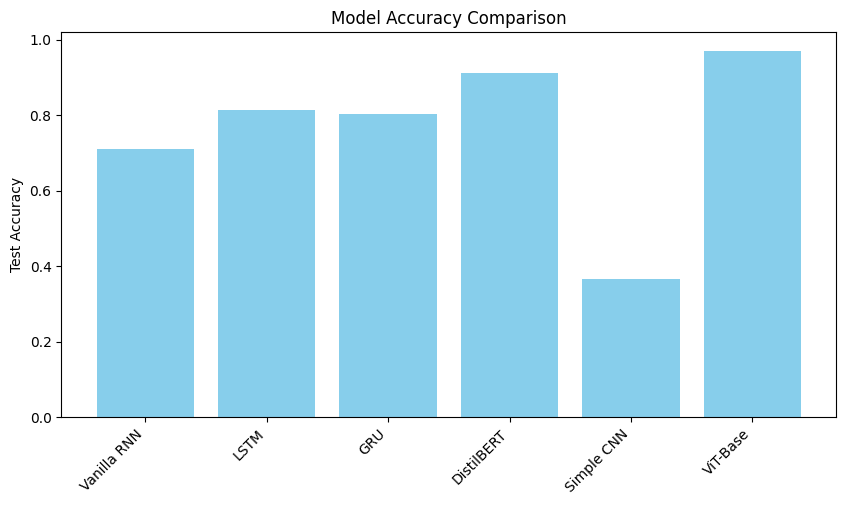

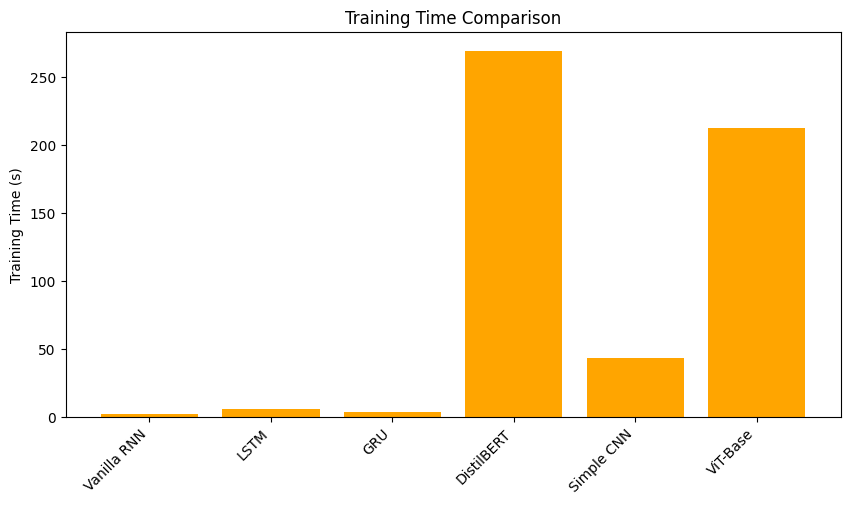

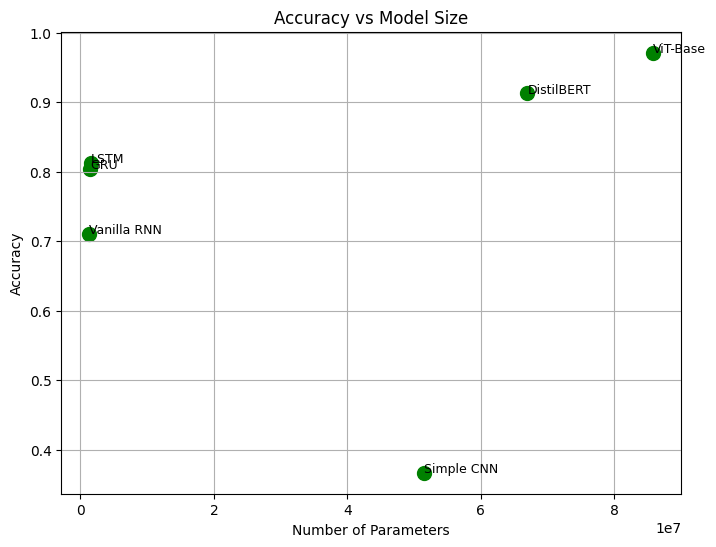

In [53]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

# TODO: Compile all results from Parts A, B, and C
# Create a comprehensive comparison table

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for nan

# 1. Compile all results

results_summary = {
    'Vanilla RNN': {
        'task': 'Text Classification',
        'accuracy': vanilla_history['test_acc'][-1],
        'train_time': sum(vanilla_history['epoch_times']),
        'parameters': sum(p.numel() for p in vanilla_rnn.parameters()),
        'strengths': 'Simple, fast, low compute',
        'weaknesses': 'Poor long-range memory, vanishing gradients',
        'use_cases': 'Short text, low-resource tasks'
    },
    'LSTM': {
        'task': 'Text Classification',
        'accuracy': lstm_history['test_acc'][-1],
        'train_time': sum(lstm_history['epoch_times']),
        'parameters': sum(p.numel() for p in lstm_model.parameters()),
        'strengths': 'Handles long-term dependencies, stable training',
        'weaknesses': 'Slower than RNN, sequential bottleneck',
        'use_cases': 'Sentiment analysis, sequence modeling'
    },
    'GRU': {
        'task': 'Text Classification',
        'accuracy': gru_history['test_acc'][-1],
        'train_time': sum(gru_history['epoch_times']),
        'parameters': sum(p.numel() for p in gru_model.parameters()),
        'strengths': 'Efficient, fewer parameters than LSTM',
        'weaknesses': 'Still sequential, weaker than Transformers',
        'use_cases': 'Chatbots, lightweight NLP'
    },
    'DistilBERT': {
        'task': 'Text Classification',
        'accuracy': bert_history['test_acc'][-1],
        'train_time': sum(bert_history['epoch_times']),
        'parameters': sum(p.numel() for p in bert_model.parameters()),
        'strengths': 'Global attention, strong pretrained language understanding',
        'weaknesses': 'Heavy compute, slower training',
        'use_cases': 'Modern NLP tasks, high-accuracy text classification'
    },
    'Simple CNN': {
        'task': 'Image Classification',
        'accuracy': cnn_accuracy,
        'train_time': cnn_train_time,
        'parameters': cnn_params,
        'strengths': 'Fast, efficient, strong inductive biases',
        'weaknesses': 'Limited global understanding',
        'use_cases': 'Small datasets, real-time vision'
    },
    'Typical CNN (reference)': {
        'task': 'Image Classification',
        'accuracy': 0.80,
        'train_time': 'Varies',
        'parameters': 'Varies',
        'strengths': 'Excellent performance on CIFAR-10, efficient',
        'weaknesses': 'Still local, limited long-range reasoning',
        'use_cases': 'Most practical vision tasks'
    },
    'ViT-Base': {
        'task': 'Image Classification',
        'accuracy': vit_history['test_acc'][-1],
        'train_time': sum(vit_history['epoch_times']),
        'parameters': sum(p.numel() for p in vit_model.parameters()),
        'strengths': 'Global attention, high accuracy, scales with data',
        'weaknesses': 'Heavy compute, needs pretraining',
        'use_cases': 'High-accuracy vision tasks, large datasets'
    }
}

# Convert to DataFrame
df_results = pd.DataFrame(results_summary).T
display(df_results)

# Filter out 'Typical CNN (reference)' for numerical plots as it contains 'Varies' strings
df_plot = df_results[df_results['train_time'] != 'Varies'].copy()
df_plot['train_time'] = pd.to_numeric(df_plot['train_time'])
df_plot['parameters'] = pd.to_numeric(df_plot['parameters'])

# 2. Visualizations

# --- Accuracy Bar Chart ---
plt.figure(figsize=(10,5))
plt.bar(df_plot.index, df_plot['accuracy'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# --- Training Time Bar Chart ---
plt.figure(figsize=(10,5))
plt.bar(df_plot.index, df_plot['train_time'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Training Time (s)")
plt.title("Training Time Comparison")
plt.show()

# --- Accuracy vs Parameters Scatter Plot ---
plt.figure(figsize=(8,6))
plt.scatter(df_plot['parameters'], df_plot['accuracy'], s=100, c='green')

for model in df_plot.index:
    plt.text(df_plot.loc[model, 'parameters'],
             df_plot.loc[model, 'accuracy'],
             model, fontsize=9)

plt.xlabel("Number of Parameters")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size")
plt.grid(True)
plt.show()

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.


---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.

For me, the most surprising result was the performance of ViT compared to CNN. I ended up with a margin of 97.1% accuracy vs. 36.7% accuracy. I thought CNN would perform better, something closer to 75-80%. I was also surprised by the training time when I was working with ViT is took a while to finish training, but my result were better, of course.

---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?

A couple of errors that come to mind happened during the three way RNN comparision in A.7. The error messages were `lstm_history` and `gru_history`, so to fix it, I run the training cells of GRU and LSTM. I learned that I need to analize the lab and check not only the steps before but also the ones after because sometimes the solution is not that complicated.

---

### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?

One epoch of LSTM took about 5.19 seconds, one epoch of DistilBERT took 269 seconds, and one epoch of ViT took 209 seconds. I thought working with transformers would be slower, but I didnt expect that it would be that slow. But again, we need to choose our model according to what we are doing, if I was working with a huge dataset and had the time and recourses I would use ViT.

---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?

I think the first image was the clearest; it was the airplane one. The ViT focused on the wings and fuselage. Also, the car image was one of the cleares and I could tell right away what it was. It was very interesting to see how the attention mechanism of vision transformers worked; unlike CNNs that only use fixed filters, ViT seems to understand the entire shape at once.

---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?

I didn't have huge issues with any cell because I was practically done with the previous version of this lab last week, but the cells that gave me some issues even in this new version of the lab were A.7, B.6, and C.4. Gemini's assistance was very helpful, and the explanations of every step help me understand the lab. Also, B.6 BERT training took a long time, probably 35+ minutes, but its performance was is way better.

---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?

The vanishing gradient problem is when gradients become extremelly small during backpropagation, which makes early layers learn slowly or just stop learning. In the lab, the vanilla RNN reached only 71.05%, while LSTM 81.3%, and GRU 80.4%, so watching the RNN don't make much progress while LSTM and GRU continued improving help me understand how the vanishing gradient problem works in the real world.

---

### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?

I think one of the things that I learned from doing this lab was how architectures affect performance. Being able to practice different labs is something that I really enjoy from this class, when learning from just lectures is not something I dislike, I do learn better when I actually do the things that I'm learning about. I would consider myself a kinesthetic learned, so even when sometimes I feel a little bit lost with some parts of the lab, I have enough resources to my disposal to be able to figure it out.

**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**





---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*